# Thực hành Regression: Dự đoán số lượt thuê xe đạp theo giờ (UCI Bike Sharing)

**Mục tiêu:** dự đoán tổng số lượt thuê xe trong một giờ (`cnt`) từ thông tin thuê xe từ dữ liệu quá khứ theo thời gian và thời tiết.

**Quy trình:** hiểu bài toán → nạp dữ liệu → EDA → làm sạch → tạo đặc trưng → chia train/test đúng cách → baseline → huấn luyện → đánh giá → diễn giải → kết luận.

## 1. Hiểu bài toán

-   Dữ liệu: hệ thống Capital Bikeshare (Washington D.C.), dữ liệu trong 2 năm 2011–2012, mỗi dòng là một giờ.  
    Nguồn: [https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (file hour.csv).
-   Target: cnt = casual (khách vãng lai) + registered (khách đăng ký). Đây là số đếm nên ≥ 0.
-   Loại bài toán: regression trên dữ liệu có yếu tố thời gian.
-   Metric:
    -   MAE (Mean Absolute Error): sai số trung bình tính bằng "số lượt thuê", dễ giải thích cho người kinh doanh.
    -   RMSE (Root Mean Squared Error): phạt nặng các giờ đoán sai nhiều, ví dụ giờ cao điểm.


## 2. Nạp dữ liệu

### 2.1 Import thư viện

In [ ]:
import io
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

In [ ]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CSV_PATH = DATA_DIR / "hour.csv"
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

def load_bike_hour():
    if not CSV_PATH.exists():
        print("Chưa có file, đang tải từ UCI ...")
        try:
            with urllib.request.urlopen(UCI_ZIP_URL, timeout=60) as resp:
                zf = zipfile.ZipFile(io.BytesIO(resp.read()))
            with zf.open("hour.csv") as src, open(CSV_PATH, "wb") as dst:
                dst.write(src.read())
            print("Đã lưu:", CSV_PATH.resolve())
        except Exception as e:
            raise RuntimeError(
                f"Không tải được dữ liệu ({e}).\n"
                "Tải thủ công: mở https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset, "
                "bấm Download, giải nén và chép file hour.csv vào thư mục data/ cạnh notebook."
            )
    else:
        print("Dùng file đã cache:", CSV_PATH.resolve())
    return pd.read_csv(CSV_PATH, parse_dates=["dteday"])

df = load_bike_hour()
print(df.shape)
df.head()

Dùng file đã cache: /workspace/dl-course/practice/data/hour.csv
(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Dataset có 17.379 dòng × 17 cột, mỗi dòng là một giờ

## 3. EDA (Exploratory Data Analysis)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
instant,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


### 3.1 Phân phối của target `cnt` - nhìn cột giờ ta thấy mỗi giờ sẽ thống kê lượt đăng kí

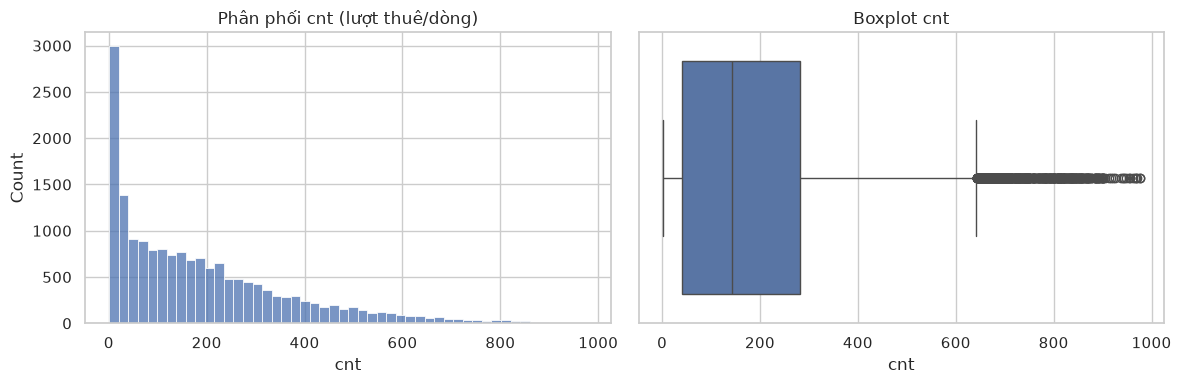

Trung bình: 189.5 | Trung vị: 142 | Max: 977


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["cnt"], bins=50, ax=ax[0])
ax[0].set_title("Phân phối cnt (lượt thuê/dòng)")
sns.boxplot(x=df["cnt"], ax=ax[1])
ax[1].set_title("Boxplot cnt")
plt.tight_layout(); plt.show()
print(f"Trung bình: {df['cnt'].mean():.1f} | Trung vị: {df['cnt'].median():.0f} | Max: {df['cnt'].max()}")

# fig, ax = plt.subplots(1, 2, figsize=(14, 4))
# sns.boxplot(data=df, x="hr", y="cnt", ax=ax[0])
# ax[0].set_title("cnt theo giờ trong ngày")
# sns.pointplot(data=df, x="hr", y="cnt", hue="workingday", errorbar=None, ax=ax[1])
# ax[1].set_title("cnt trung bình theo giờ: ngày làm việc và ngày nghỉ")
# plt.tight_layout(); plt.show()

Cột cao nhất của histogram nằm ở khoảng 0–20 lượt, với gần 3.000 giờ.
Sau đó tần suất giảm dần, kéo dài tới gần 1.000.
Boxplot: 50% số giờ nằm trong khoảng 40–281 lượt, trung vị 142. Từ khoảng 640 lượt trở lên là một dải dài các điểm ngoại lai.
Nhận xét: Phân phối cnt lệch phải mạnh,đến từ xu hướng thông thường,phần lớn các khung giờ đêm,rạng sáng sẽ có ít lượt thuê, và tnưg ở các khung giờ cao điểm. Vì vậy RMSE sẽ lớn hơn MAE khá nhiều, do bị kéo bởi các giờ đông.

### 3.2 Xu hướng theo thời gian

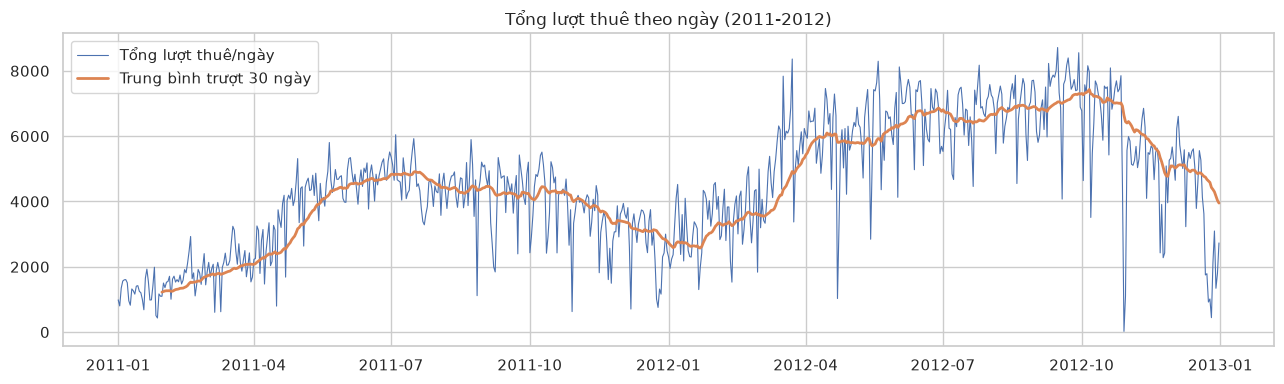

In [ ]:
daily = df.groupby("dteday")["cnt"].sum() # gộp 24 giờ thành tổng lượt thuê của 1 ngày → 731 ngày
plt.figure(figsize=(13, 4))
plt.plot(daily.index, daily.values, lw=0.8, label="Tổng lượt thuê/ngày")
plt.plot(daily.index, daily.rolling(30).mean(), lw=2, label="Trung bình trượt 30 ngày")   # trung bình 30 ngày gần nhất
plt.title("Tổng lượt thuê theo ngày (2011-2012)")
plt.legend(); plt.tight_layout(); plt.show()

Phân tích xu hướng tổng quan theo chuỗi thời gian các ngày, tháng trong từng năm từ 2011 đến đầu 2013:
Sử dụng kỹ thuật tính tổng lượng thuê xe đạp theo tổng thời gian theo ngày
groupby("dteday")["cnt"].sum(): gom 24 dòng (24 giờ) của cùng một ngày lại và cộng cnt, nên mỗi ngày còn một con số là tổng lượt thuê của ngày đó. Kết quả ứng với 2 năm.
Đường mảnh: vẽ tổng lượt thuê của từng ngày. Đường này dao động khác nhau cho các ngày và các tháng, cho thấy xu hướng nhu cầu thuê, sử dụng xe đạp sẽ thay đổi theo ngày và các lên xuống rất nhiều vì mỗi ngày mỗi khác: ngày mưa thì ít khách, ngày đẹp trời thì đông.
Đường đậm rolling(30).mean(): tại mỗi ngày, lấy trung bình của 30 ngày gần nhất tính đến ngày đó. Cách này làm mượt các dao động ngày qua ngày, chỉ giữ lại xu hướng lớn. 29 ngày đầu chưa đủ 30 ngày để tính nên bị bỏ trống.
Trong đó: 
- Mùa vụ: mùa hè và đầu thu đông khách, mùa đông vắng khách, và năm nào cũng lặp lại như vậy. 
Ví dụ: Giai đoạn tháng 1-2/2011 ghi nhận ~1.300-1.800 lượt trung bình/ngày , điểm nhu cầu thấp nhất trong năm. Giai đoạn đỉnh của năm 2011 rơi vào khoảng tháng 6-9/2011, ~4.300-4.900 lượt/ngày
- Xu hướng tăng trưởng: Cùng một mùa, năm 2012 cao hơn năm 2011 
Đáy mùa đông tăng từ ≈ 1.300 (đầu 2011) lên ≈ 2.700 (đầu 2012), khoảng gấp đôi.
Đỉnh mùa hè tăng từ ≈ 4.900 lên ≈ 7.300, khoảng +50%. Có thể thấy dịch vụ trong giai đoạn này đang mở rộng

Hệ quả cho mô hình hoá:

Không thể chia train/test ngẫu nhiên, vì sẽ trộn quá khứ với tương lai. Phải chia theo thời gian.
Giai đoạn test (09–12/2012) nằm ở mức cao nhất từ trước tới nay. Mô hình học chủ yếu từ giai đoạn thấp hơn, nên có xu hướng đoán thấp. 

### 3.3 Theo giờ trong ngày: ngày làm việc và ngày nghỉ

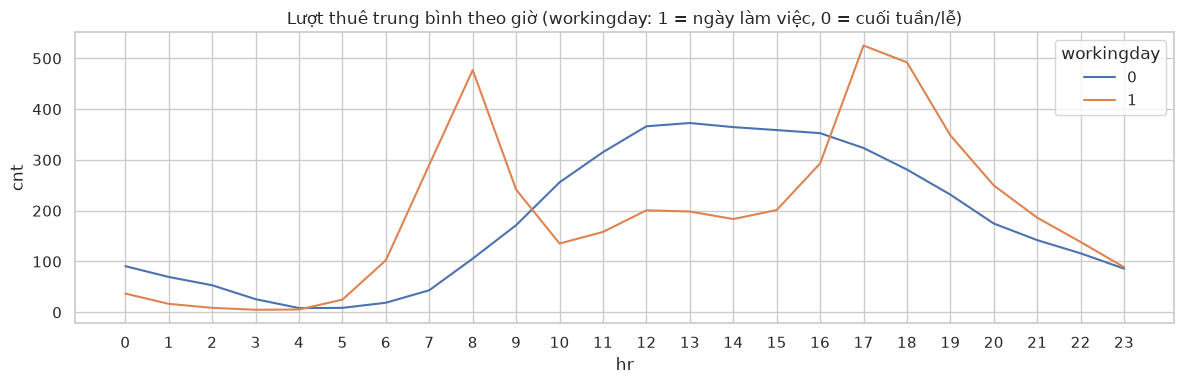

In [7]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="hr", y="cnt", hue="workingday", estimator="mean", errorbar=None)
plt.title("Lượt thuê trung bình theo giờ (workingday: 1 = ngày làm việc, 0 = cuối tuần/lễ)")
plt.xticks(range(24)); plt.tight_layout(); plt.show()

Ngày làm việc (cam): hai đỉnh nhọn, ≈ 480 lượt lúc 8h và ≈ 525 lượt lúc 17h (18h vẫn ≈ 490). Giữa trưa chỉ ≈ 140–200. Rạng sáng 3–4h gần bằng 0.
Ngày nghỉ (xanh): một đỉnh rộng, dạng bình nguyên ≈ 350–375 lượt từ 12h đến 16h, không có đỉnh sáng và chiều. Lúc 0–2h đêm cao hơn ngày làm việc (≈ 90 so với ≈ 40), do người ta đi chơi khuya cuối tuần.

Kết luận:

Có hai kiểu hành vi chia theo ngày làm việc và ngày nghỉ. Nhu cầu cho hai loại ngày cũng khác biệt . Ví dụ 8h ngày làm việc gấp khoảng 4–5 lần 8h ngày nghỉ.
Đây là tương tác hr × workingday. Mô hình tuyến tính đơn giản không bắt được tương tác này, nên mô hình cây và MLP phù hợp hơn. Đây là lý do bài báo cáo này sử dụng mô hình MLP bên cạnh các mô hình cây.

### 3.4 Thời tiết và mùa

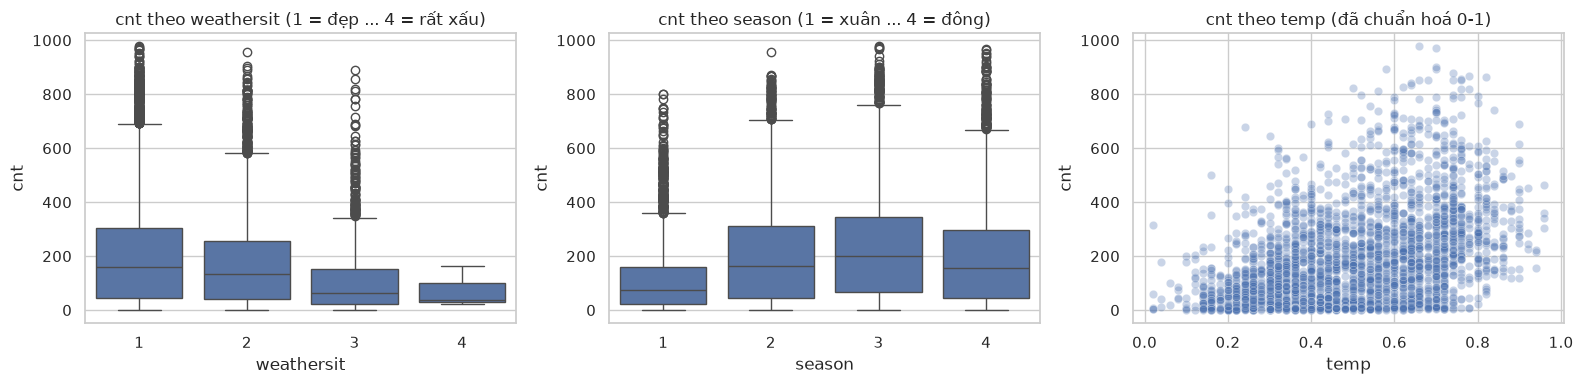

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="weathersit", y="cnt", ax=ax[0])
ax[0].set_title("cnt theo weathersit (1 = đẹp ... 4 = rất xấu)")
sns.boxplot(data=df, x="season", y="cnt", ax=ax[1])
ax[1].set_title("cnt theo season (1 = xuân ... 4 = đông)")
sns.scatterplot(data=df.sample(3000, random_state=SEED), x="temp", y="cnt", alpha=0.3, ax=ax[2])
ax[2].set_title("cnt theo temp (đã chuẩn hoá 0-1)")
plt.tight_layout(); plt.show()
print(df["weathersit"].value_counts().sort_index())

Theo thời tiết: trung vị khoảng 160 khi trời đẹp (1), 135 khi có mây hoặc sương mù (2), giảm còn ≈ 60 khi mưa nhỏ (3), ≈ 35 khi mưa to (4). Nhóm 4 chỉ có 3 giờ trong toàn bộ dữ liệu.
Theo mùa: xuân (1) thấp nhất (trung vị ≈ 75), thu (3) cao nhất (≈ 200), hè (2) và đông (4) ở giữa (≈ 160).
Theo nhiệt độ: các chấm dâng lên khi temp tăng tới ≈ 0,7–0,8 (khoảng 25–30°C), sau đó hơi chững lại. Nhưng tại cùng một mức nhiệt, cnt vẫn trải rộng từ 0 tới 800.

Kết luận:

Thời tiết xấu làm giảm mạnh lượt thuê. Mưa làm giảm hơn một nửa.
Trời ấm thì có nhiều lượt thuê hơn, nhưng nhiệt độ một mình không giải thích được nhiều. Độ trải theo chiều dọc rộng là do yếu tố giờ trong ngày.
weathersit = 4 quá hiếm, nên mô hình gần như không học được gì từ nhóm này.

### 3.5 Tương quan

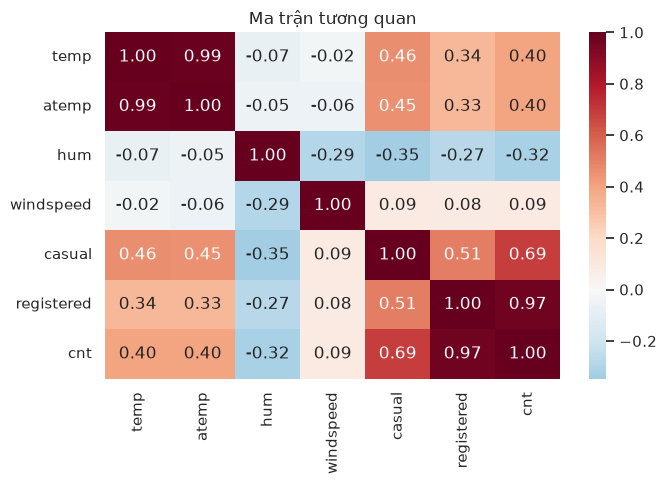

In [9]:
num_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Ma trận tương quan"); plt.tight_layout(); plt.show()

Phân tích ma trận tương quan

-   casual và registered tương quan rất cao với cnt, là thành phần cấu tạo nên target. Nhóm không đưa phần này vào feature tránh việc Data Leakage
-   temp và atemp gần như trùng nhau (tương quan ≈ 0.99). 
-   hum: Độ ẩm cao thì ít khách. Gió hầu như không ảnh hưởng.
Khách vãng lai “đi theo thời tiết” nhiều hơn khách đăng ký

In [10]:
print("Missing values:", int(df.isna().sum().sum()))
print("Dòng trùng lặp:", int(df.duplicated().sum()))
hours_per_day = df.groupby("dteday").size()
print(f"Số ngày: {hours_per_day.size} | Số giờ kỳ vọng: {hours_per_day.size * 24} | Thực tế: {len(df)}")
print("Số ngày thiếu ít nhất 1 giờ:", int((hours_per_day < 24).sum()))
print("Số dòng hum = 0 (độ ẩm 0%, nhiều khả năng lỗi cảm biến):", int((df["hum"] == 0).sum()))
print("Số dòng windspeed = 0:", int((df["windspeed"] == 0).sum()))

Missing values: 0
Dòng trùng lặp: 0
Số ngày: 731 | Số giờ kỳ vọng: 17544 | Thực tế: 17379
Số ngày thiếu ít nhất 1 giờ: 76
Số dòng hum = 0 (độ ẩm 0%, nhiều khả năng lỗi cảm biến): 22
Số dòng windspeed = 0: 2180


Nhận xét: Không có missing hay trùng lặp. Một số giờ bị thiếu (có thể hệ thống ngừng hoạt động, hoặc giờ đó không có ai thuê nên không được ghi). Hợp lệ
Có vài dòng hum = 0 và khá nhiều dòng windspeed = 0 (có thể là giá trị thiếu được ghi thành 0).

In [11]:
TARGET = "cnt"
DROP_COLS = ["instant", "casual", "registered", "atemp"]  # leakage / ID / trùng thông tin
df_clean = df.drop(columns=DROP_COLS).sort_values(["dteday", "hr"]).reset_index(drop=True)
df_clean.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.75,0.0,1


5. Tạo đặc trưng (feature)

Dùng các feature có sẵn và biết trước được tại thời điểm dự đoán (lịch và dự báo thời tiết):

| Nhóm | Feature |
| --- | --- |
| Thời gian | hr, weekday, mnth, season, yr |
| Lịch | holiday, workingday |
| Thời tiết | weathersit, temp, hum, windspeed |


In [12]:
df_clean["datetime"] = df_clean["dteday"] + pd.to_timedelta(df_clean["hr"], unit="h")
FEATURES = ["hr", "weekday", "mnth", "season", "yr", "holiday", "workingday",
            "weathersit", "temp", "hum", "windspeed"]
print("Số feature:", len(FEATURES))
df_clean[["datetime"] + FEATURES + [TARGET]].head()

Số feature: 11


,datetime,hr,weekday,mnth,season,yr,holiday,workingday,weathersit,temp,hum,windspeed,cnt
0,2011-01-01 00:00:00,0,6,1,1,0,0,0,1,0.24,0.81,0.0,16
1,2011-01-01 01:00:00,1,6,1,1,0,0,0,1,0.22,0.80,0.0,40
2,2011-01-01 02:00:00,2,6,1,1,0,0,0,1,0.22,0.80,0.0,32
3,2011-01-01 03:00:00,3,6,1,1,0,0,0,1,0.24,0.75,0.0,13
4,2011-01-01 04:00:00,4,6,1,1,0,0,0,1,0.24,0.75,0.0,1


6. Chia train/test theo thời gian

-   Train: 2011-01-01 → 2012-08-31 (20 tháng đầu)
-   Test: 2012-09-01 → 2012-12-31 (4 tháng cuối)
-   Không shuffle ngẫu nhiên.

In [13]:
SPLIT_DATE = pd.Timestamp("2012-09-01")
train = df_clean[df_clean["dteday"] < SPLIT_DATE].copy()
test = df_clean[df_clean["dteday"] >= SPLIT_DATE].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Train: {len(train):>6} dòng | {train['dteday'].min().date()} → {train['dteday'].max().date()} | cnt TB = {y_train.mean():.1f}")
print(f"Test : {len(test):>6} dòng | {test['dteday'].min().date()} → {test['dteday'].max().date()} | cnt TB = {y_test.mean():.1f}")

Train:  14491 dòng | 2011-01-01 → 2012-08-31 | cnt TB = 179.3
Test :   2888 dòng | 2012-09-01 → 2012-12-31 | cnt TB = 240.2


Nhận xét: cnt trung bình ở test cao hơn ở train, vì test nằm ở cuối 2012 khi lượng người dùng đã tăng. -> có thể bị dự đoán kém đi vì chỗ cnt chỗ test nhiêu hơn train.

7. Baseline: trung bình cnt theo (giờ, thứ) trên train

Chọn theo (giờ, thứ) vì EDA cho thấy lượng khách phụ thuộc mạnh nhất vào giờ trong ngày và vào ngày làm việc hay ngày nghỉ

In [14]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(np.asarray(y_pred) - np.asarray(y_true))  # < 0: đoán thấp hơn thực tế
    return {"Model": name, "MAE": mae, "RMSE": rmse, "Bias (dự đoán - thực tế)": bias}

baseline_table = train.groupby(["hr", "weekday"])[TARGET].mean().rename("baseline_pred")
test = test.join(baseline_table, on=["hr", "weekday"])
test["baseline_pred"] = test["baseline_pred"].fillna(y_train.mean())  # phòng trường hợp thiếu tổ hợp

results = [evaluate("Baseline: mean(hr, weekday)", y_test, test["baseline_pred"])]
pd.DataFrame(results).round(2)

,Model,MAE,RMSE,Bias (dự đoán - thực tế)
0,"Baseline: mean(hr, weekday)",94.47,139.27,-61.58


8. HistGradientBoostingRegressor Model Training


In [15]:
model = HistGradientBoostingRegressor(random_state=SEED)
model.fit(X_train, y_train)

test["model_pred"] = np.clip(model.predict(X_test), 0, None)  # số lượt thuê không thể âm
train_pred = np.clip(model.predict(X_train), 0, None)

results.append(evaluate("HistGradientBoosting", y_test, test["model_pred"]))
print("Số vòng boosting đã dùng:", model.n_iter_)

Số vòng boosting đã dùng: 100


### 8.1 Benchmark thêm: RandomForestRegressor và LightGBM

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor   

train_preds = {"HistGradientBoosting": train_pred}   # dự đoán trên train, dùng để kiểm tra overfitting
pred_cols = {"HistGradientBoosting": "model_pred"}    # tên cột dự đoán trong bảng test

benchmarks = {
    "RandomForest": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=SEED, verbose=-1),
}
for name, m in benchmarks.items():
    m.fit(X_train, y_train)
    col = f"{name.lower()}_pred"
    test[col] = np.clip(m.predict(X_test), 0, None)         
    train_preds[name] = np.clip(m.predict(X_train), 0, None)
    pred_cols[name] = col
    results.append(evaluate(name, y_test, test[col]))       
    print(f"Đã huấn luyện {name}")

Đã huấn luyện RandomForest


Đã huấn luyện LightGBM


### 8.2 Mạng nơ-ron MLP (PyTorch)

In [17]:
import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

CAT_COLS = ["hr", "weekday", "mnth", "season", "weathersit"]      # one-hot
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]              # scale
CFG = dict(hidden=[128, 64], dropout=0.1, lr=1e-3, batch_size=256,
           max_epochs=300, patience=20, y_scale=100.0)
VAL_START = pd.Timestamp("2012-07-01")                             # 2 tháng cuối của train làm validation
torch.set_num_threads(4)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def make_preprocess():
    return ColumnTransformer([
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
    ])

fit_part = train[train["dteday"] < VAL_START]
val_part = train[train["dteday"] >= VAL_START]
prep_fit = make_preprocess()
X_fit = prep_fit.fit_transform(fit_part[FEATURES]).astype(np.float32)   # fit CHỈ trên phần train
X_val = prep_fit.transform(val_part[FEATURES]).astype(np.float32)
print(f"Fit       : {len(fit_part):>6} dòng | {fit_part['dteday'].min().date()} → {fit_part['dteday'].max().date()}")
print(f"Validation: {len(val_part):>6} dòng | {val_part['dteday'].min().date()} → {val_part['dteday'].max().date()}")
print("Số cột sau scaling + one-hot:", X_fit.shape[1], f"({len(NUM_COLS)} cột số + {X_fit.shape[1] - len(NUM_COLS)} cột one-hot)")

Fit       :  13003 dòng | 2011-01-01 → 2012-06-30
Validation:   1488 dòng | 2012-07-01 → 2012-08-31
Số cột sau scaling + one-hot: 57 (6 cột số + 51 cột one-hot)


In [18]:
class MLP(nn.Module):
    """Input -> [Linear -> ReLU -> Dropout] x k -> Linear(1)"""
    def __init__(self, in_dim, hidden, dropout):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

@torch.no_grad()
def mlp_predict(net, Xa):
    net.eval()
    out = net(torch.from_numpy(Xa)).numpy() * CFG["y_scale"]
    return np.clip(out, 0, None).astype(np.float64)               # số lượt thuê không thể âm

def train_mlp(Xtr, ytr, Xva=None, yva=None, epochs=None, seed=SEED, verbose=True):
    """Có (Xva, yva): early stopping theo val loss. Không có: chạy đúng `epochs` epoch."""
    set_seed(seed)
    net = MLP(Xtr.shape[1], CFG["hidden"], CFG["dropout"])
    criterion = nn.L1Loss()                                         # L1 = MAE
    optimizer = torch.optim.Adam(net.parameters(), lr=CFG["lr"])
    ds = TensorDataset(torch.from_numpy(Xtr),
                       torch.tensor(np.asarray(ytr) / CFG["y_scale"], dtype=torch.float32))
    loader = DataLoader(ds, batch_size=CFG["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    hist = {"train_loss": [], "val_loss": []}
    best_loss, best_state, best_epoch, wait = np.inf, None, 0, 0
    for epoch in range(1, (epochs or CFG["max_epochs"]) + 1):
        net.train()
        tot = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(net(xb), yb)
            loss.backward()
            optimizer.step()
            tot += loss.item() * len(xb)
        hist["train_loss"].append(tot / len(ds) * CFG["y_scale"])   # đổi về đơn vị lượt thuê/giờ
        if Xva is None:
            continue
        val_loss = mean_absolute_error(yva, mlp_predict(net, Xva))
        hist["val_loss"].append(val_loss)
        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"Epoch {epoch:3d} | train loss {hist['train_loss'][-1]:6.2f} | val loss {val_loss:6.2f}")
        if val_loss < best_loss - 1e-3:
            best_loss, best_epoch, wait = val_loss, epoch, 0
            best_state = {k: v.detach().clone() for k, v in net.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG["patience"]:
                if verbose:
                    print(f"Early stopping ở epoch {epoch} (val loss tốt nhất = {best_loss:.2f} ở epoch {best_epoch})")
                break
    if best_state is not None:
        net.load_state_dict(best_state)
    return net, hist, best_epoch, best_loss

mlp_es, mlp_hist, best_epoch, best_val = train_mlp(X_fit, fit_part[TARGET], X_val, val_part[TARGET])
print(mlp_es)

Epoch   1 | train loss 117.25 | val loss 138.55


Epoch  10 | train loss  27.41 | val loss  42.98


Epoch  20 | train loss  24.13 | val loss  48.57


Epoch  30 | train loss  23.13 | val loss  48.34


Epoch  40 | train loss  21.99 | val loss  48.11


Epoch  50 | train loss  21.43 | val loss  44.22


Early stopping ở epoch 53 (val loss tốt nhất = 39.85 ở epoch 33)
MLP(
  (net): Sequential(
    (0): Linear(in_features=57, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


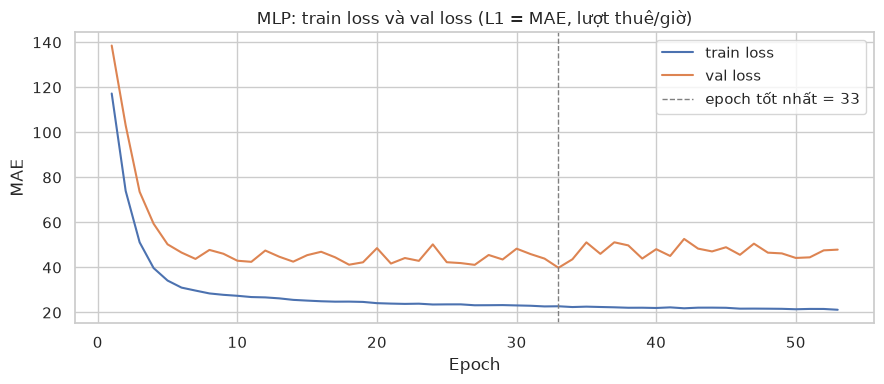

In [19]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(mlp_hist["train_loss"]) + 1), mlp_hist["train_loss"], label="train loss")
plt.plot(range(1, len(mlp_hist["val_loss"]) + 1), mlp_hist["val_loss"], label="val loss")
plt.axvline(best_epoch, color="gray", ls="--", lw=1, label=f"epoch tốt nhất = {best_epoch}")
plt.title("MLP: train loss và val loss (L1 = MAE, lượt thuê/giờ)")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend(); plt.tight_layout(); plt.show()

Train loss giảm đều từ 117 xuống ≈ 22.
Val loss giảm rất nhanh trong khoảng 10 epoch đầu (138 → 43), sau đó dao động trong khoảng 40–52 chứ không giảm tiếp. Giá trị tốt nhất đạt ở epoch 33 (39,85).

In [20]:
prep_full = make_preprocess()
X_train_mlp = prep_full.fit_transform(X_train).astype(np.float32)   # fit CHỈ trên train
X_test_mlp = prep_full.transform(X_test).astype(np.float32)

mlp, _, _, _ = train_mlp(X_train_mlp, y_train, epochs=best_epoch)
test["mlp_pred"] = mlp_predict(mlp, X_test_mlp)
train_preds["MLP (PyTorch)"] = mlp_predict(mlp, X_train_mlp)
pred_cols["MLP (PyTorch)"] = "mlp_pred"
results.append(evaluate("MLP (PyTorch)", y_test, test["mlp_pred"]))   # cùng hàm evaluate, cùng danh sách results
print(f"MLP huấn luyện lại trên toàn bộ train: {best_epoch} epoch, {len(X_train_mlp)} dòng")
pd.DataFrame(results).round(2)

MLP huấn luyện lại trên toàn bộ train: 33 epoch, 14491 dòng


,Model,MAE,RMSE,Bias (dự đoán - thực tế)
0,"Baseline: mean(hr, weekday)",94.47,139.27,-61.58
1,HistGradientBoosting,45.06,67.02,-16.23
2,RandomForest,48.51,74.04,-19.37
3,LightGBM,44.76,66.86,-19.73
4,MLP (PyTorch),39.91,61.49,4.40


In [21]:
seed_rows = []
for s in [SEED, 0, 1, 2, 3]:
    _, _, ep_s, val_s = train_mlp(X_fit, fit_part[TARGET], X_val, val_part[TARGET], seed=s, verbose=False)
    net_s, _, _, _ = train_mlp(X_train_mlp, y_train, epochs=ep_s, seed=s, verbose=False)
    pred_s = mlp_predict(net_s, X_test_mlp)
    row = evaluate(f"MLP seed {s}", y_test, pred_s)
    row.update({"Số epoch": ep_s, "MAE val": val_s, "Dự đoán lớn nhất": pred_s.max()})
    seed_rows.append(row)
seed_df = pd.DataFrame(seed_rows).set_index("Model")
display(seed_df.round(2))
print(f"MAE test qua {len(seed_df)} seed: trung bình {seed_df['MAE'].mean():.2f}, "
      f"thấp nhất {seed_df['MAE'].min():.2f}, cao nhất {seed_df['MAE'].max():.2f}")

,MAE,RMSE,Bias (dự đoán - thực tế),Số epoch,MAE val,Dự đoán lớn nhất
Model,,,,,,
MLP seed 42,39.91,61.49,4.40,33,39.85,909.90
MLP seed 0,52.60,74.47,29.78,27,37.07,888.50
MLP seed 1,43.84,66.89,11.64,33,34.56,934.33
MLP seed 2,43.99,64.93,19.11,27,38.35,899.36
MLP seed 3,46.74,68.98,22.63,17,37.48,899.94


MAE test qua 5 seed: trung bình 45.42, thấp nhất 39.91, cao nhất 52.60


9. Đánh giá

9.1 Bảng so sánh MAE / RMSE trên test

In [22]:
res = pd.DataFrame(results).set_index("Model")
base_mae = res.loc["Baseline: mean(hr, weekday)", "MAE"]
res["MAE giảm so với baseline (%)"] = 100 * (base_mae - res["MAE"]) / base_mae

# MAE trên train (kiểm tra overfitting). Baseline: bảng tra (hr, weekday) áp lên chính train.
baseline_train_pred = train.join(baseline_table, on=["hr", "weekday"])["baseline_pred"]
all_train_preds = {"Baseline: mean(hr, weekday)": baseline_train_pred, **train_preds}
res["MAE train"] = [mean_absolute_error(y_train, all_train_preds[m]) for m in res.index]
display(res.round(2))

print("Kiểm tra overfitting (MAE train và MAE test):")
for m in res.index:
    tr = evaluate(m, y_train, all_train_preds[m])
    print(f"  {m:<28} MAE train = {tr['MAE']:6.2f} | MAE test = {res.loc[m, 'MAE']:6.2f} | "
          f"test/train = {res.loc[m, 'MAE'] / tr['MAE']:.2f} | Bias train = {tr['Bias (dự đoán - thực tế)']:6.2f}")
print(f"Giá trị cnt trung bình: train = {y_train.mean():.1f} | test = {y_test.mean():.1f}")

,MAE,RMSE,Bias (dự đoán - thực tế),MAE giảm so với baseline (%),MAE train
Model,,,,,
"Baseline: mean(hr, weekday)",94.47,139.27,-61.58,0.00,68.47
HistGradientBoosting,45.06,67.02,-16.23,52.31,22.14
RandomForest,48.51,74.04,-19.37,48.65,8.70
LightGBM,44.76,66.86,-19.73,52.62,17.94
MLP (PyTorch),39.91,61.49,4.40,57.75,19.44


Kiểm tra overfitting (MAE train và MAE test):
  Baseline: mean(hr, weekday)  MAE train =  68.47 | MAE test =  94.47 | test/train = 1.38 | Bias train =  -0.00
  HistGradientBoosting         MAE train =  22.14 | MAE test =  45.06 | test/train = 2.03 | Bias train =   0.03
  RandomForest                 MAE train =   8.70 | MAE test =  48.51 | test/train = 5.58 | Bias train =   0.42
  LightGBM                     MAE train =  17.94 | MAE test =  44.76 | test/train = 2.50 | Bias train =   0.06
  MLP (PyTorch)                MAE train =  19.44 | MAE test =  39.91 | test/train = 2.05 | Bias train =  -5.10
Giá trị cnt trung bình: train = 179.3 | test = 240.2


Mô hình cây có bias âm (đoán thấp), MLP có bias dương (đoán cao).
MAE trên train thấp hơn test 2–5 lần. Một phần do overfitting, một phần do test có mặt bằng cao hơn.

### 9.2 Dự đoán và thực tế trong khoảng 2 tuần của test

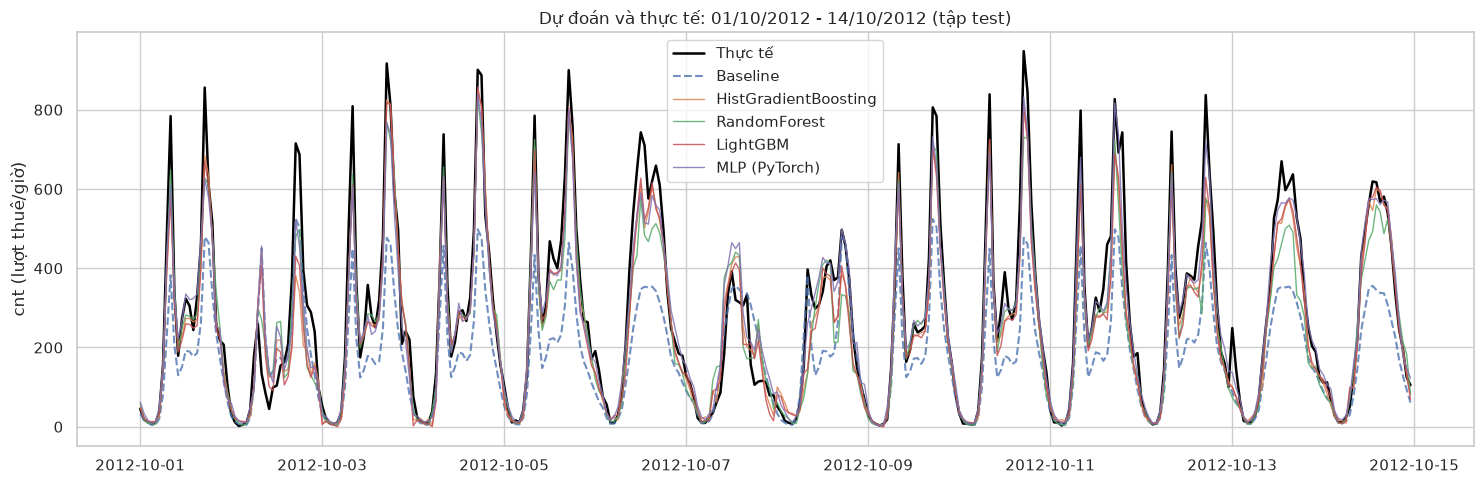

In [23]:
win = test[(test["datetime"] >= "2012-10-01") & (test["datetime"] < "2012-10-15")]
plt.figure(figsize=(15, 5))
plt.plot(win["datetime"], win[TARGET], label="Thực tế", color="black", lw=1.8)
plt.plot(win["datetime"], win["baseline_pred"], label="Baseline", ls="--", alpha=0.8)
for name, col in pred_cols.items():
    plt.plot(win["datetime"], win[col], label=name, lw=1, alpha=0.85)
plt.title("Dự đoán và thực tế: 01/10/2012 - 14/10/2012 (tập test)")
plt.ylabel("cnt (lượt thuê/giờ)"); plt.legend(); plt.tight_layout(); plt.show()

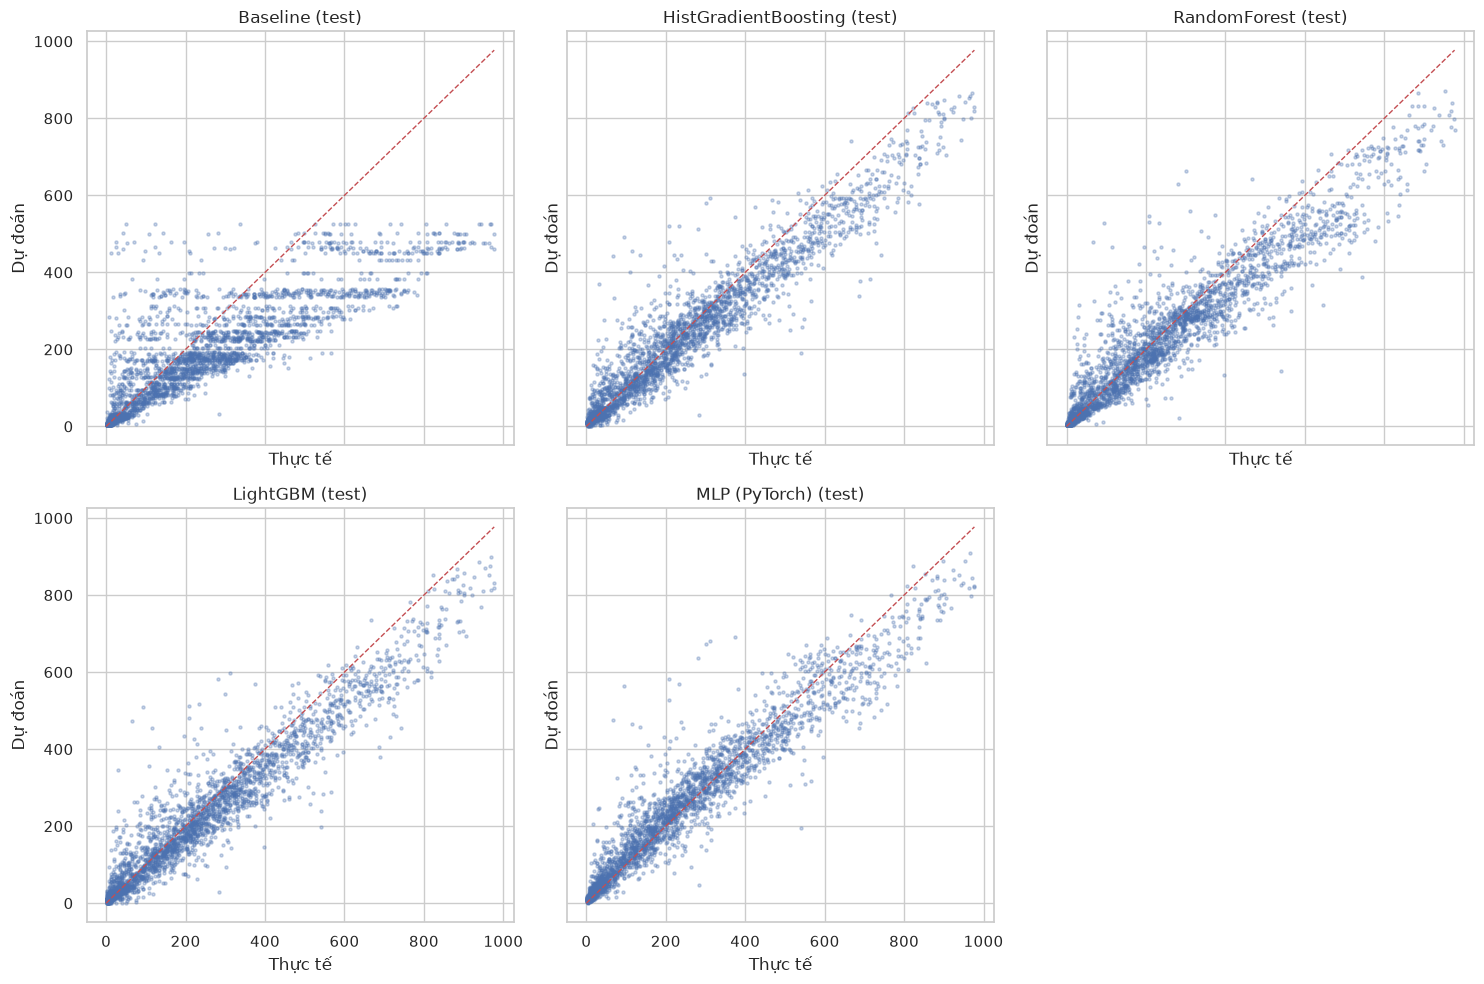

In [24]:
panels = [("Baseline", "baseline_pred")] + [(n, c) for n, c in pred_cols.items()]
ncols = 3
nrows = int(np.ceil(len(panels) / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), sharex=True, sharey=True)
ax = ax.ravel()
for a, (name, col) in zip(ax, panels):
    a.scatter(test[TARGET], test[col], s=5, alpha=0.3)
    lim = [0, max(test[TARGET].max(), test[col].max())]
    a.plot(lim, lim, "r--", lw=1)
    a.set(title=f"{name} (test)", xlabel="Thực tế", ylabel="Dự đoán")
for a in ax[len(panels):]:
    a.axis("off")
plt.tight_layout(); plt.show()

Mọi mô hình đều tái tạo đúng nhịp ngày: hai đỉnh vào ngày làm việc, đỉnh trưa vào cuối tuần (06–07/10 và 13–14/10).
Baseline (nét đứt) thấp hơn thực tế rõ rệt ở mọi đỉnh.
Mô hình cây và MLP bắt đúng thời điểm đỉnh nhưng thường không chạm tới độ cao đỉnh thực tế (khoảng 800–950).

### 9.3 Sai số theo giờ trong ngày

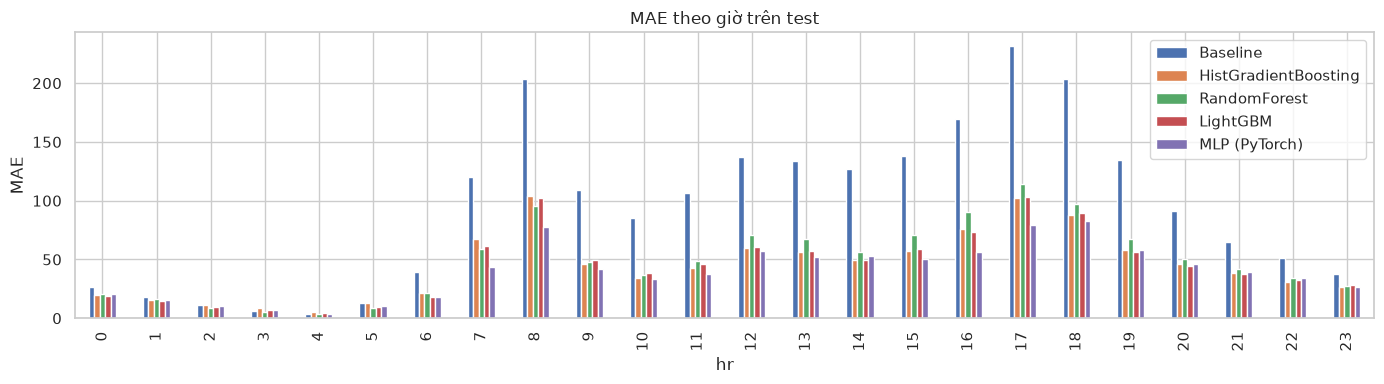

In [25]:
err_by_hr = pd.DataFrame({"Baseline": (test[TARGET] - test["baseline_pred"]).abs()})
for name, col in pred_cols.items():
    err_by_hr[name] = (test[TARGET] - test[col]).abs()
err_by_hr = err_by_hr.groupby(test["hr"]).mean()
err_by_hr.plot(kind="bar", figsize=(14, 4), title="MAE theo giờ trên test")
plt.ylabel("MAE"); plt.tight_layout(); plt.show()

MAE theo giờ:

Sai số rất nhỏ trong khoảng 0–6h (dưới 20).
Sai số lớn nhất ở 8h và 17–18h: baseline ≈ 200–230, các mô hình ≈ 80–115.
MLP có sai số thấp nhất ở các giờ cao điểm (≈ 77–83).

### 9.4 Kiểm tra: model có ngoại suy được xu hướng tăng không?

So sánh `cnt` **trung bình theo tháng** ở test với dự đoán trung bình của từng model, đồng thời so **giá trị dự đoán lớn nhất** với `cnt` lớn nhất trong train.

In [26]:

monthly = test.groupby(test["datetime"].dt.to_period("M")).agg(
    **{"Thực tế": (TARGET, "mean"), "Baseline": ("baseline_pred", "mean")},
    **{name: (col, "mean") for name, col in pred_cols.items()})
display(monthly.round(1))

print(f"cnt lớn nhất trong train: {y_train.max()} | trong test: {y_test.max()}")
for name, col in pred_cols.items():
    print(f"  {name:<22} dự đoán lớn nhất trên test = {test[col].max():7.1f}")


,Thực tế,Baseline,HistGradientBoosting,RandomForest,LightGBM,MLP (PyTorch)
datetime,,,,,,
2012-09,303.6,178.0,281.8,278.3,282.9,294.8
2012-10,280.8,179.2,250.6,247.9,246.9,267.1
2012-11,212.6,179.2,200.2,191.3,194.3,231.5
2012-12,166.7,178.3,165.6,167.9,160.1,187.2


cnt lớn nhất trong train: 957 | trong test: 977
  HistGradientBoosting   dự đoán lớn nhất trên test =   866.0
  RandomForest           dự đoán lớn nhất trên test =   871.5
  LightGBM               dự đoán lớn nhất trên test =   898.4
  MLP (PyTorch)          dự đoán lớn nhất trên test =   909.9


10. Diễn giải: Importance feature 

,feature,MAE tăng khi xáo trộn,std
0,hr,147.07,1.67
1,temp,32.76,0.85
2,workingday,32.66,1.21
3,hum,8.63,0.70
4,weekday,7.54,0.46
5,weathersit,3.80,0.35
6,season,2.41,0.13
7,mnth,1.58,0.08
8,windspeed,0.28,0.08
9,yr,0.00,0.00


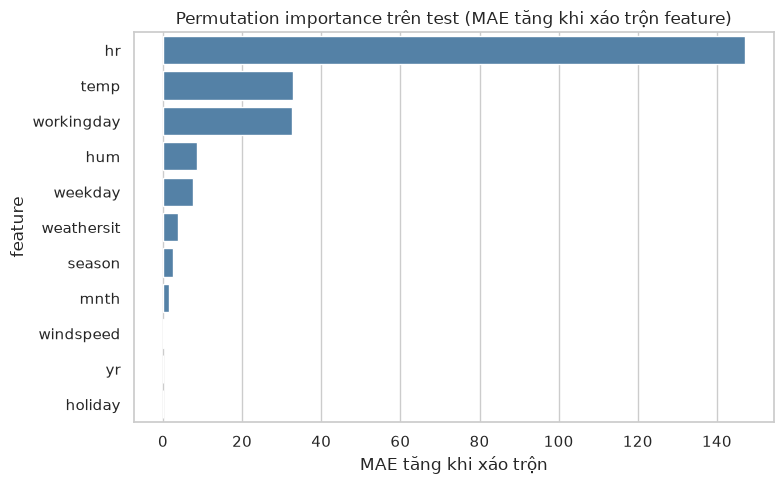

In [27]:
perm = permutation_importance(model, X_test, y_test, scoring="neg_mean_absolute_error",
                              n_repeats=5, random_state=SEED, n_jobs=-1)
imp = (pd.DataFrame({"feature": FEATURES,
                     "MAE tăng khi xáo trộn": perm.importances_mean,
                     "std": perm.importances_std})
       .sort_values("MAE tăng khi xáo trộn", ascending=False)
       .reset_index(drop=True))
display(imp.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=imp, y="feature", x="MAE tăng khi xáo trộn", color="steelblue")
plt.title("Permutation importance trên test (MAE tăng khi xáo trộn feature)")
plt.tight_layout(); plt.show()

Thứ tự quan trọng khớp với EDA: giờ trong ngày quyết định nhiều nhất, tiếp theo là nhiệt độ và loại ngày.
yr = 0 không có nghĩa là năm không quan trọng. Trong test, yr luôn bằng 1, nên xáo trộn cột này không thay đổi gì.
holiday ≈ 0 vì thông tin này đã nằm trong workingday, và test có rất ít ngày lễ.

## 11. Kết luận

In [28]:
print(res.round(2).to_string())
print("\nTop-3 feature theo permutation importance (HistGradientBoosting):", ", ".join(imp["feature"].head(3)))
print(f"\nMLP qua 5 seed: MAE test trung bình {seed_df['MAE'].mean():.2f} "
      f"(từ {seed_df['MAE'].min():.2f} đến {seed_df['MAE'].max():.2f})")

                               MAE    RMSE  Bias (dự đoán - thực tế)  MAE giảm so với baseline (%)  MAE train
Model                                                                                                        
Baseline: mean(hr, weekday)  94.47  139.27                    -61.58                          0.00      68.47
HistGradientBoosting         45.06   67.02                    -16.23                         52.31      22.14
RandomForest                 48.51   74.04                    -19.37                         48.65       8.70
LightGBM                     44.76   66.86                    -19.73                         52.62      17.94
MLP (PyTorch)                39.91   61.49                      4.40                         57.75      19.44

Top-3 feature theo permutation importance (HistGradientBoosting): hr, temp, workingday

MLP qua 5 seed: MAE test trung bình 45.42 (từ 39.91 đến 52.60)


Tóm tắt kết quả (lần chạy này, tập test 01/09/2012 → 31/12/2012, 2,888 giờ):

| Model | MAE | RMSE | Bias (dự đoán − thực tế) | MAE giảm so với baseline (%) | MAE train |
| --- | --- | --- | --- | --- | --- |
| Baseline: mean(hr, weekday) | 94.47 | 139.27 | −61.58 | 0.00 | 68.47 |
| HistGradientBoosting | 45.06 | 67.02 | −16.23 | 52.31 | 22.14 |
| RandomForest | 48.51 | 74.04 | −19.37 | 48.65 | 8.70 |
| LightGBM | 44.76 | 66.86 | −19.73 | 52.62 | 17.94 |
| MLP (PyTorch, seed 42) | 39.91 | 61.49 | 4.40 | 57.75 | 19.44 |

1.  Mọi model đều tốt hơn baseline rõ rệt: MAE giảm 48.65% đến 57.75%. Trong 3 tree model, LightGBM (44.76) và HistGradientBoosting (45.06) gần như ngang nhau, RandomForest kém hơn một chút (48.51).
2.  MLP (seed 42) có MAE và RMSE thấp nhất bảng (39.91 và 61.49). Nhưng khi chạy lại đúng quy trình với 5 seed (42, 0, 1, 2, 3), MAE test dao động từ 39.91 đến 52.60, trung bình 45.42, tức là ngang LightGBM và HistGradientBoosting. Seed 42 lại là seed tốt nhất trong 5 seed. Seed có MAE val thấp nhất (seed 1, 34.56) cũng không phải seed tốt nhất trên test (43.84). Vì vậy không thể kết luận MLP tốt hơn tree model: trên bài này MLP ngang ngửa boosting nhưng kém ổn định hơn nhiều. Tree model gần như không đổi theo seed.
3.  Hướng lệch khác nhau: các tree model đều đoán thấp (bias −16.23 đến −19.73), còn MLP là model duy nhất đoán cao (bias 4.40 với seed 42, từ 11.64 đến 29.78 với 4 seed còn lại). Theo tháng, MLP sát thực tế hơn tree ở tháng 9 (294.8 so với 303.6) và tháng 10 (267.1 so với 280.8), nhưng lại đoán cao ở tháng 11 (231.5 so với 212.6) và tháng 12 (187.2 so với 166.7), là hai tháng mà tree model đoán gần đúng.
4.  Ngoại suy: về lý thuyết MLP có thể dự đoán vượt mức của train, nhưng thực tế dự đoán lớn nhất của MLP là 909.9 (5 seed: 888.5 đến 934.33), vẫn thấp hơn cnt lớn nhất trong train (957), trong khi test có giờ lên tới 977. Nghĩa là MLP không thật sự học được xu hướng tăng tiếp. Nó chỉ nâng mặt bằng dự đoán lên cao hơn tree model, và nâng cả ở những tháng không cần. Lý do có thể là: bộ feature không có biến thời gian liên tục (chỉ có yr), và tổ hợp yr = 2012 với tháng 9–12 chưa từng xuất hiện trong train, nên mỗi model "đoán" tổ hợp này theo cách riêng: cây dựa vào giá trị train gần nhất, MLP cộng dồn hiệu ứng yr và tháng.
5.  Kiểm tra overfitting (MAE test / MAE train): HistGradientBoosting 2.03 lần, MLP 2.05 lần (19.44 → 39.91), LightGBM 2.50 lần, RandomForest 5.58 lần (8.70 → 48.51). RandomForest gần như học thuộc train nhưng tệ nhất trên test. Bias train của MLP là −5.10 (các model khác gần 0) vì loss L1 làm mạng dự đoán gần trung vị, mà cnt lệch phải nên trung vị thấp hơn trung bình.
6.  Sai số lớn nhất ở giờ cao điểm (8h và 17–18h) với mọi model. MLP giảm sai số ở các giờ cao điểm rõ hơn tree model (xem biểu đồ MAE theo giờ).
7.  Diễn giải (permutation importance của HistGradientBoosting): hr quan trọng nhất (MAE tăng 147.07 khi xáo trộn), sau đó là temp (32.76) và workingday (32.66), tiếp đến hum và weekday. yr ra 0 chỉ vì nó không biến thiên trong test, không phải vì vô dụng.

Hạn chế và hướng cải thiện (chưa làm):

-   Thêm lag feature (ví dụ cnt của giờ trước, của cùng giờ hôm qua) nếu bài toán là dự báo ngắn hạn, khi đó các giá trị này đã biết tại thời điểm dự đoán.
-   Thử dự đoán log1p(cnt) vì target lệch phải; tune nhẹ tham số bằng TimeSeriesSplit (CV theo thời gian, không shuffle).
-   MLP: giảm phụ thuộc vào seed bằng cách lấy trung bình dự đoán của vài seed (ensemble), hoặc dùng validation dài hơn để chọn số epoch ổn định hơn.